**2.2 Q1. Implement a data generator**

In [ ]:
import numpy as np

def generate_data(
    N,              #no of samples
    Sigma,          #covariance matrix
    w,              #weight vector
    noise_type = "gaussian",
    noise_param=0.2,
    seed=0
):
    np.random.seed(seed)

    d = Sigma.shape[0]

    # Validate covariance matrix
    assert np.allclose(Sigma, Sigma.T), "Sigma must be symmetric"
    assert np.allclose(np.diag(Sigma), 1), "Diagonal must be 1"
    assert np.all(np.linalg.eigvalsh(Sigma) >= 0), "Sigma must be PSD"

    # Generate features
    X = np.random.multivariate_normal(
        mean=np.zeros(d),
        cov=Sigma,
        size=N
    )

    # Add bias if needed
    if len(w) == d + 1:
        X = np.column_stack([np.ones(N), X])

    # Generate noise
    if noise_type == "gaussian":
        epsilon = np.random.normal(0, noise_param, N)

    elif noise_type == "laplacian":
        epsilon = np.random.laplace(0, noise_param, N)

    elif noise_type == "uniform":
        epsilon = np.random.uniform(-noise_param, noise_param, N)

    else:
        raise ValueError("Unknown noise type")

    # True and noisy targets
    t_true = X @ w
    t_noisy = t_true + epsilon

    return X, t_true, t_noisy


In [ ]:
# Number of samples
N = 300

# Covariance matrix (negative correlation)
Sigma = np.array([
    [1.0, -0.8],
    [-0.8, 1.0]
])

# True weights
w = np.array([2.0, -1.0, 3.0])

# Generate data
X, t_true, t_noisy = generate_data(
    N=N,
    Sigma=Sigma,
    w=w,
    noise_param=2,
    seed=42
)

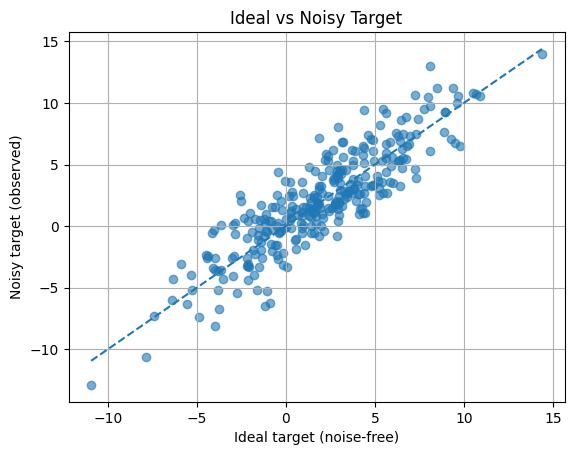

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(t_true, t_noisy, alpha=0.6)
plt.plot(
    [t_true.min(), t_true.max()],
    [t_true.min(), t_true.max()],
    linestyle="--"
)
plt.xlabel("Ideal target (noise-free)")
plt.ylabel("Noisy target (observed)")
plt.title("Ideal vs Noisy Target")
plt.grid(True)
plt.show()


we can observe here that as the ideal target is increasing the noisy target is alo increasing lineraly.There is a linear relationship between the. Secondly, we can observe the variance around the y=x line. The distribution is symmetric around the center, even if we increase the variance, we still get the distribution symmetric. so, the noise has zero mean and model is unbiased.

**2.2 Q2 show at least one visualization of two negatively correlated features using a scatter plot**

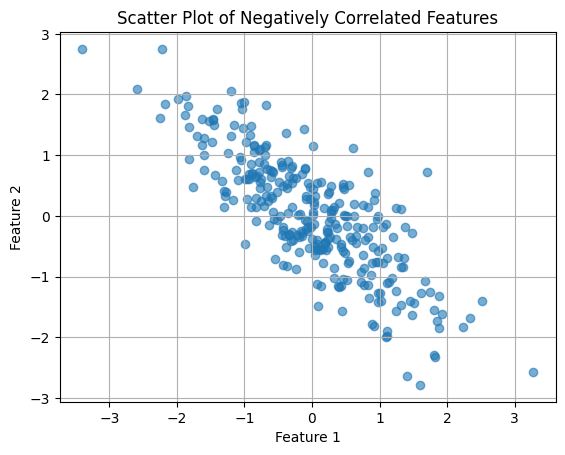

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X[:, 2], X[:, 1], alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Negatively Correlated Features")
plt.grid(True)
plt.show()


Here, we can observe that has feature 1 is increasing the feature 2 is decreasing, so they are negatively correlated.

**Q2.2 3 Implement gradient descent with L1/L2 regularization**

In [ ]:
import numpy as np

def gradient_descent(
    X, t,
    lr=0.01,
    n_iters=1000,
    reg_type=None,   # None, "l1", "l2"
    lam=0.0
):
    """
    Gradient Descent with optional L1 / L2 regularization
    """
    N, d = X.shape
    w = np.zeros(d)
    loss_history = []

    for _ in range(n_iters):
        # Prediction
        y_pred = X @ w

        # Gradient of MSE
        grad = (2 / N) * X.T @ (y_pred - t)

        # Add regularization gradient
        if reg_type == "l2":
            grad += 2 * lam * w
        elif reg_type == "l1":
            grad += lam * np.sign(w)

        # Update
        w = w - lr * grad

        # Compute loss
        mse = (1 / N) * np.sum((y_pred - t) ** 2)
        if reg_type == "l2":
            loss = mse + lam * np.sum(w ** 2)
        elif reg_type == "l1":
            loss = mse + lam * np.sum(np.abs(w))
        else:
            loss = mse

        loss_history.append(loss)

    return w, loss_history




In [ ]:
# No regularization
w_gd, loss_gd = gradient_descent(
    X, t_noisy,
    lr=0.01,
    n_iters=1000
)

# L2 regularization
w_l2, loss_l2 = gradient_descent(
    X, t_noisy,
    lr=0.01,
    n_iters=1000,
    reg_type="l2",
    lam=0.1
)

# L1 regularization
w_l1, loss_l1 = gradient_descent(
    X, t_noisy,
    lr=0.01,
    n_iters=1000,
    reg_type="l1",
    lam=0.1
)

print("Weights (No regularization):", w_gd)
print("Weights (L2 regularization):", w_l2)
print("Weights (L1 regularization):", w_l1)


Weights (No regularization): [ 2.16272983 -0.88774285  2.93310574]
Weights (L2 regularization): [ 1.96100581 -1.12689845  2.48474147]
Weights (L1 regularization): [ 2.11212747 -0.85854389  2.90358679]


Conclusion: As we can observed that with no regularization, the weights are larger. In case of L2, the weights are smaller because L2 penalizes larger weights more and shrinks it uniformly as compared to L1 which shrinks few coeffients to zero and leaves others relatively less penalized. However, in this case L1 has no irrelevant variable to eliminate, therefore, it does not zero anything.

**graph**

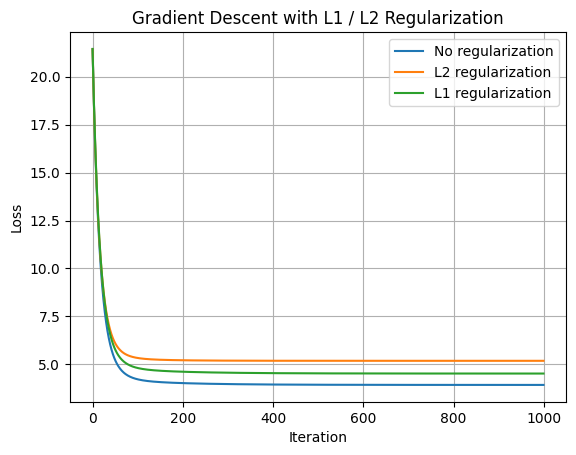

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_gd, label="No regularization")
plt.plot(loss_l2, label="L2 regularization")
plt.plot(loss_l1, label="L1 regularization")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent with L1 / L2 Regularization")
plt.legend()
plt.grid(True)
plt.show()


As we can observe that the three models successfully minimize their respective loss. The unregularized model showed the lowest training loss because it does not include a penalty term. However, L1 and L2 regularization increases the loss due to the added penalty but improve model stability. Here, regularization increases training loss but reduces model complexity.

**2.2 4 Implement ridge pseudo-inverse estimator**

In [ ]:
import numpy as np

def ridge_pseudo_inverse(X, t, lam):
    """
    Ridge regression with bias term (bias NOT regularized)
    """

    N, d = X.shape

    # Identity matrix
    I = np.eye(d)


    w_ridge = np.linalg.inv(X.T @ X + lam * I) @ X.T @ t

    return w_ridge

In [ ]:
lam = 0.1
w_ridge = ridge_pseudo_inverse(X, t_noisy, lam)

print("Ridge pseudo-inverse weights:", w_ridge)


Ridge pseudo-inverse weights: [ 2.16229748 -0.86392659  2.95593834]


**2.2 5 Build inference module with optional NRMSE/NMAE**

In [ ]:
import numpy as np

def inference_module(X, t_true, w, metric="nrmse"):
    t_pred = X @ w
    error = t_true - t_pred
    norm = np.max(t_true) - np.min(t_true)

    if metric == "nrmse":
        score = np.sqrt(np.mean(error ** 2)) / norm
    elif metric == "nmae":
        score = np.mean(np.abs(error)) / norm
    else:
        raise ValueError("Metric must be 'nrmse' or 'nmae'")

    return t_pred, score


**2.2 6 Test on synthetic data**

In [ ]:
# Test inference module on synthetic data

# Use any learned weights (example: ridge pseudo-inverse)
t_pred_nrmse, nrmse = inference_module(X, t_noisy, w_ridge, metric="nrmse")
t_pred_nmae, nmae = inference_module(X, t_noisy, w_ridge, metric="nmae")

print("NRMSE on synthetic data:", nrmse)
print("NMAE on synthetic data:", nmae)


NRMSE on synthetic data: 0.07380071202838771
NMAE on synthetic data: 0.059236183959970025


Conclusion: The values obtained for NRMSE and NMAE shows low prediction error. This suggets that our model fits the synthetic data well and generalizes effectively.

**Module 3**

Pre-question
Which estimator do you expect to be more stable: gradient descent or pseudo-inverse? Why?

Here, the ridge pseudo-inverse estimator is expected to be more stable because it directly computes the solution of the regularized objective and does not depend on hyper parameters such as learning rate. However, gradient descent is an iterative method whose stability depends on step size, how far are we from minima and the choice of learning rate. Therefore, it is generally more sensitive to optimization settings.

Post question
When do the two estimators disagree and why?
1. Gradient descent is stoped in between which is dependent on magnitude of iteration step
2. Gradient descent depends on learning step. Therefore, the optimum weight vector obtained with gradient desent would be different from ridge pseudo-inverse. Hence, the  two estimator would disagree.
3. In  ridge pseudo-inverse estimator, the calculation of inverse matrix may lead to numeric precison errors and this will affect the optimal solution.

**Module 4**


**Pre-question**
Which result do you expect to change faster with increasing N : bias or variance?

Variance changes faster with increase N because as the number of training sample increases, our model generalises better to the true distribution. Hence, parameter estimates fluctuate less and model becomes more stable.
In contrast, the bias depends more on the distribution of data and not on the number of training samples. Hence, it does not change rapidly with change in number of samples

**Q1**

N_train = 20, Variance = 0.042678, Bias² = 0.000288
N_train = 40, Variance = 0.023885, Bias² = 0.000011
N_train = 60, Variance = 0.015737, Bias² = 0.000061
N_train = 80, Variance = 0.008810, Bias² = 0.000018
N_train = 100, Variance = 0.008435, Bias² = 0.000016
N_train = 150, Variance = 0.004849, Bias² = 0.000058
N_train = 200, Variance = 0.004070, Bias² = 0.000028


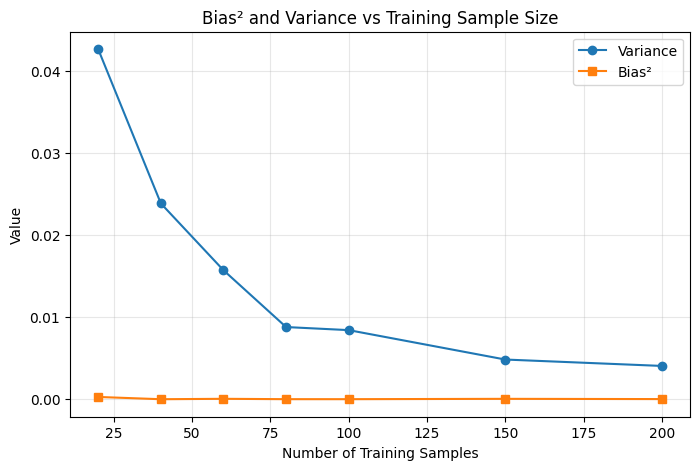

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
num_runs = 100
N_val = 1000
lam = 0.1
noise_type = "gaussian"
noise_param = 0.5

w_true = np.array([2.0, -1.0])

Sigma = np.array([
    [1.0, -0.8],
    [-0.8, 1.0]
])

N_train_values = [20, 40, 60, 80, 100, 150, 200]

variance_list = []
bias_list = []

# -----------------------------
# Fixed validation set
# -----------------------------
X_val, t_val_true, _ = generate_data(
    N=N_val,
    Sigma=Sigma,
    w=w_true,
    noise_type=noise_type,
    noise_param=noise_param,
    seed=999
)

X_val_bias = np.column_stack((np.ones(X_val.shape[0]), X_val))

# -----------------------------
# Loop over training sizes
# -----------------------------
for N_train in N_train_values:

    all_predictions = []

    for i in range(num_runs):

        X_train, t_train_true, t_train_noisy = generate_data(
            N=N_train,
            Sigma=Sigma,
            w=w_true,
            noise_type=noise_type,
            noise_param=noise_param,
            seed=i
        )

        X_train_bias = np.column_stack((np.ones(X_train.shape[0]), X_train))

        w_ridge = np.linalg.inv(
            X_train_bias.T @ X_train_bias + lam * np.diag([0,1,1])
        ) @ X_train_bias.T @ t_train_noisy

        t_pred = X_val_bias @ w_ridge
        all_predictions.append(t_pred)

    all_predictions = np.array(all_predictions)

    # Variances8
    variance = np.mean(np.var(all_predictions, axis=0))
    variance_list.append(variance)

    # Bias^2
    mean_prediction = np.mean(all_predictions, axis=0)
    bias_sq = np.mean((mean_prediction - t_val_true) ** 2)
    bias_list.append(bias_sq)

    print(f"N_train = {N_train}, Variance = {variance:.6f}, Bias² = {bias_sq:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(N_train_values, variance_list, marker='o', label="Variance")
plt.plot(N_train_values, bias_list, marker='s', label="Bias²")
plt.xlabel("Number of Training Samples")
plt.ylabel("Value")
plt.title("Bias² and Variance vs Training Sample Size")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Conclusion: As we can observe from the graph that as the number of sample size of training data increases the variance of predictions on validation data decreases. Larger datasets produce more stable and reliable estimators. Thus. we can conclude that as variance shrinks as N increases. But, for bias value, it does not change much as the number of training size increases.

Q2 Show MSE beats MAE under Gaussian noise and Q3 Show MAE beats MSE under Laplacian noise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
num_runs = 100
N_train = 80
N_val = 300
lam = 0.1
noise_param = 0.8

w_true = np.array([2.0, -1.0])
Sigma = np.array([
    [1.0, -0.8],
    [-0.8, 1.0]
])

def evaluate_correct(noise_type):

    # Fixed validation set
    X_val, t_val_true, t_val_noisy = generate_data(
        N=N_val,
        Sigma=Sigma,
        w=w_true,
        noise_type=noise_type,
        noise_param=noise_param,
        seed=999
    )

    X_val_bias = np.column_stack((np.ones(X_val.shape[0]), X_val))

    mse_model_errors = []
    mae_model_errors = []

    for i in range(num_runs):

        X_train, t_train_true, t_train_noisy = generate_data(
            N=N_train,
            Sigma=Sigma,
            w=w_true,
            noise_type=noise_type,
            noise_param=noise_param,
            seed=i
        )

        X_train_bias = np.column_stack((np.ones(X_train.shape[0]), X_train))

        # -------- MSE model (Ridge) --------
        w_mse = np.linalg.inv(
            X_train_bias.T @ X_train_bias + lam * np.diag([0,1,1])
        ) @ X_train_bias.T @ t_train_noisy

        # -------- MAE model (L1) --------
        w_mae, _ = gradient_descent(
            X_train,
            t_train_noisy,
            lr=0.01,
            n_iters=2000,
            reg_type="l1",
            lam=lam
        )
        w_mae = np.insert(w_mae, 0, 0)

        pred_mse = X_val_bias @ w_mse
        pred_mae = X_val_bias @ w_mae

        # IMPORTANT: evaluation metric depends on noise type

        if noise_type == "gaussian":
            # Evaluate BOTH using MSE
            mse_model_errors.append(np.mean((t_val_noisy - pred_mse)**2))
            mae_model_errors.append(np.mean((t_val_noisy - pred_mae)**2))

        elif noise_type == "laplacian":
            # Evaluate BOTH using MAE
            mse_model_errors.append(np.mean(np.abs(t_val_noisy - pred_mse)))
            mae_model_errors.append(np.mean(np.abs(t_val_noisy - pred_mae)))

    return mse_model_errors, mae_model_errors


# -----------------------------
# Gaussian Noise
# -----------------------------
mse_gauss_list, mae_gauss_list = evaluate_correct("gaussian")

print("Gaussian Noise (Evaluation = MSE)")
print("MSE-trained mean:", np.mean(mse_gauss_list))
print("MAE-trained mean:", np.mean(mae_gauss_list))


# -----------------------------
# Laplacian Noise
# -----------------------------
mse_lap_list, mae_lap_list = evaluate_correct("laplacian")

print("\nLaplacian Noise (Evaluation = MAE)")
print("MSE-trained mean:", np.mean(mse_lap_list))
print("MAE-trained mean:", np.mean(mae_lap_list))


Gaussian Noise (Evaluation = MSE)
MSE-trained mean: 0.7199009738079635
MAE-trained mean: 0.7170396467158012

Laplacian Noise (Evaluation = MAE)
MSE-trained mean: 0.7781108810057933
MAE-trained mean: 0.7694607373869637


/tmp/ipython-input-864135469.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


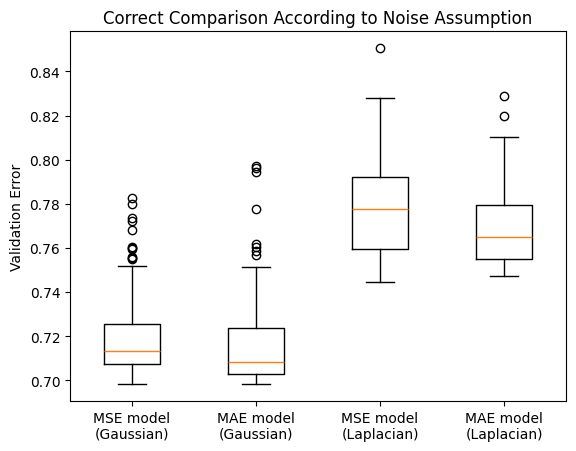

In [ ]:
plt.figure()

plt.boxplot([
    mse_gauss_list,
    mae_gauss_list,
    mse_lap_list,
    mae_lap_list
],
labels=[
    "MSE model\n(Gaussian)",
    "MAE model\n(Gaussian)",
    "MSE model\n(Laplacian)",
    "MAE model\n(Laplacian)"
])

plt.ylabel("Validation Error")
plt.title("Correct Comparison According to Noise Assumption")
plt.show()


Conclusion: From graph it is observed that under gaussian noise, the overall distribution of MSE is slightly lower than MAE. However, the median of MSE is slightly higher than MAE. Secondly, under laplacian noise, the distribution of MAE is lower than MSE and also the median of MAE is lower. So, we can conclude that loss function is more sensitive to laplacian noise but not to gaussian noise

**Post question**
Which result contradicted your intuition?

We expected larger differnce between MSE and MAE under gaussian noise but the observed difference was very minimal. This shows us that loss function is not much sensitive to gaussian errors in comparision to laplacian error

**Module 5**

**Pre-question**
Why should λ = 0 almost never be optimal?

λ = 0  cannot be optimal because real data has some correlation and if we dont regularize, our estimator tries to only minimize MSE loss and thus not give importance to value of weights. Thus, the optimal weight becomes larger because at low MSE our weights are higher. Consequently, the variance of prediction increases. Introducing a small positive λ reduces variance by stabilizing the estimator, while only slightly increasing bias.

**1. Empirically confirm that validation error minimized at λ > 0**

Best lambda: 1.0353218432956626
Minimum validation MSE: 1.1118374215888716


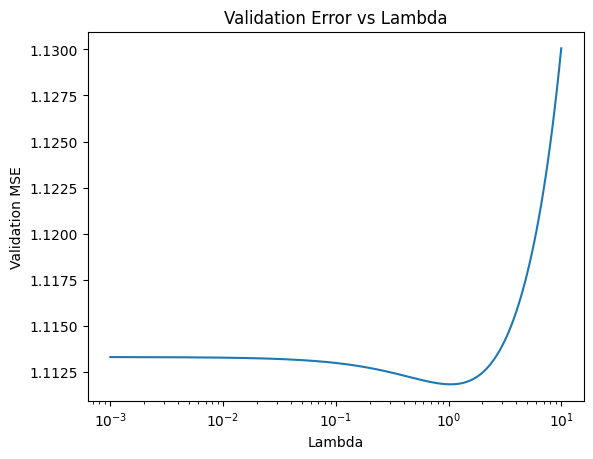

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
N_train = 200
N_val = 300
noise_param = 1
noise_type = "gaussian"   # change to "laplacian" if needed

w_true = np.array([2.0, -1.0])
Sigma = np.array([
    [1.0, -0.98],
    [-0.98, 1.0]
])

# -----------------------------
# Generate training data
# -----------------------------
X_train, t_train_true, t_train_noisy = generate_data(
    N=N_train,
    Sigma=Sigma,
    w=w_true,
    noise_type=noise_type,
    noise_param=noise_param,
    seed=42
)

# Add bias
X_train_bias = np.column_stack((np.ones(X_train.shape[0]), X_train))

# -----------------------------
# Generate validation data
# -----------------------------
X_val, t_val_true, t_val_noisy = generate_data(
    N=N_val,
    Sigma=Sigma,
    w=w_true,
    noise_type=noise_type,
    noise_param=noise_param,
    seed=999
)

X_val_bias = np.column_stack((np.ones(X_val.shape[0]), X_val))

# -----------------------------
# Try different lambda values
# -----------------------------
lambda_values = np.logspace(-3, 1, 200)
validation_errors = []

for lam in lambda_values:

    # Ridge solution
    w_ridge = np.linalg.inv(
        X_train_bias.T @ X_train_bias + lam * np.diag([0,1,1])
    ) @ X_train_bias.T @ t_train_noisy

    # Predict on validation set
    t_pred = X_val_bias @ w_ridge

    # Compute validation MSE
    val_mse = np.mean((t_val_noisy - t_pred)**2)
    validation_errors.append(val_mse)

# Convert to array
validation_errors = np.array(validation_errors)

# -----------------------------
# Find best lambda
# -----------------------------
best_index = np.argmin(validation_errors)
best_lambda = lambda_values[best_index]

print("Best lambda:", best_lambda)
print("Minimum validation MSE:", validation_errors[best_index])

# -----------------------------
# Plot validation curve
# -----------------------------
plt.figure()
plt.semilogx(lambda_values, validation_errors)
plt.xlabel("Lambda")
plt.ylabel("Validation MSE")
plt.title("Validation Error vs Lambda")
plt.show()


Conclusion:

As we can observe from the graph, for very small λ, the model behaves like ordinary least squares and thus has low validation error. However, as λ increases, the error initially remains stable but then increases sharply due to over-regularization and underfitting. The optimal λ near zero, indicating that in this region, the dataset is sufficiently stable and does not require strong regularization.

**2. Demonstrate L1 variable elimination**

In [ ]:
import numpy as np

# -----------------------------
# Create higher-dimensional data
# -----------------------------
N = 150
d = 10   # 10 features

# True weights (only first 2 matter)
w_true = np.array([2.0, -1.5] + [0]*(d-2))

# Feature covariance (identity)
Sigma = np.eye(d)

# Generate data
X = np.random.multivariate_normal(
    mean=np.zeros(d),
    cov=Sigma,
    size=N
)

t_true = X @ w_true
noise = np.random.normal(0, 0.5, N)
t_noisy = t_true + noise

# -----------------------------
# Train L1 (Lasso via GD)
# -----------------------------
w_l1, _ = gradient_descent(
    X,
    t_noisy,
    lr=0.01,
    n_iters=3000,
    reg_type="l1",
    lam=0.5
)

# -----------------------------
# Train L2 (Ridge via GD)
# -----------------------------
w_l2, _ = gradient_descent(
    X,
    t_noisy,
    lr=0.01,
    n_iters=3000,
    reg_type="l2",
    lam=0.5
)

print("True weights:")
print(w_true)

print("\nL1 estimated weights:")
print(w_l1)

print("\nL2 estimated weights:")
print(w_l2)

True weights:
[ 2.  -1.5  0.   0.   0.   0.   0.   0.   0.   0. ]

L1 estimated weights:
[ 1.72928382e+00 -1.26470429e+00 -6.88745830e-04  1.84807923e-03
  2.06566418e-03  2.05899360e-03  7.67926770e-05  4.03234719e-03
  6.76045487e-04  2.13286696e-03]

L2 estimated weights:
[ 1.27885676 -1.02066731  0.05996816  0.00272539  0.06147713 -0.01143945
 -0.01273236  0.09197596 -0.07098711  0.04359203]


Conclusion:
As we can see, the most of the L1 estimated weights are nearly equal to zero, this suggest that L1 regularization pushes weights to zero which leads to corresponding variable or features to be eliminated. In conttarst, in L2 estimated weights, we can observe that all of them are shrinked uniformly but does not eliminate variables

**3. Show instability with correlated features and stabilization via L2**

In [ ]:
import numpy as np

# -----------------------------
# SETTINGS
# -----------------------------
num_runs = 50
N = 60
lam = 0.5   # L2 strength

# Highly correlated covariance
Sigma = np.array([
    [1.0, 0.99],
    [0.99, 1.0]
])

w_true = np.array([2.0, -2.0])

weights_no_reg = []
weights_l2 = []

for i in range(num_runs):

    X, t_true, t_noisy = generate_data(
        N=N,
        Sigma=Sigma,
        w=w_true,
        noise_type="gaussian",
        noise_param=0.8,
        seed=i
    )

    # Add bias
    X_bias = np.column_stack((np.ones(X.shape[0]), X))

    # -------- No regularization (OLS) --------
    w_ols = np.linalg.inv(
        X_bias.T @ X_bias
    ) @ X_bias.T @ t_noisy

    # -------- L2 regularization (Ridge) --------
    w_ridge = np.linalg.inv(
        X_bias.T @ X_bias + lam * np.diag([0,1,1])
    ) @ X_bias.T @ t_noisy

    weights_no_reg.append(w_ols)
    weights_l2.append(w_ridge)

weights_no_reg = np.array(weights_no_reg)
weights_l2 = np.array(weights_l2)

print("Standard deviation of weights (No Regularization):")
print(np.std(weights_no_reg, axis=0))

print("\nStandard deviation of weights (L2 Regularization):")
print(np.std(weights_l2, axis=0))

Standard deviation of weights (No Regularization):
[0.10746244 0.77448541 0.76959107]

Standard deviation of weights (L2 Regularization):
[0.10720752 0.4100959  0.40134038]


Conclusion:

From results, it can be observed that when, the features are highly correlated and you dont add regularization, variation observed in weightis more. But, when we add L2 regularization, the varaition is less among the weights.

**Post-question**


When does L1 fail to stabilize correlated features?

When our data has higly correlated features, if we choose L1 regularization, it promotes sparcity and selects certain features over others. This selection of features varies over training samples and hence, we see larger variation in our predictions. L2 regularization shrinks correlated features together. Instead of eliminating one, it distributes weight across correlated variables. This improves numerical stability and reduces variance more smoothly.